# Análisis de enriquecimiento, pruebas estadisticas

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.stats import hypergeom
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator
from IPython.display import display

In [11]:
# --- 1. CONFIGURACIÓN Y CARGA DE DATOS ---
print("Cargando y configurando entorno...")
# Asegúrate de que las rutas sean correctas para tu entorno
# Ajusta estas rutas si es necesario
BASE_OUTPUT_DIR = os.path.join(os.path.dirname(os.getcwd()), "output")
FINAL_CLUSTER_RESULTS_DIR = os.path.join(BASE_OUTPUT_DIR, "Trial_2")
MODULE_ANALYSIS_SUMMARY_PATH = os.path.join(FINAL_CLUSTER_RESULTS_DIR, "hdbscan_module_analysis_summary.csv")

try:
    df = pd.read_csv(MODULE_ANALYSIS_SUMMARY_PATH)
    print(f"✅ Archivo '{os.path.basename(MODULE_ANALYSIS_SUMMARY_PATH)}' cargado exitosamente.")
    print(f"Total de módulos: {len(df)}")
    display(df.head())
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo en la ruta: {MODULE_ANALYSIS_SUMMARY_PATH}")
    print("Por favor, verifica que la ruta y el nombre del archivo sean correctos.")
    df = None # Asegura que df no esté definido si hay un error


Cargando y configurando entorno...
✅ Archivo 'hdbscan_module_analysis_summary.csv' cargado exitosamente.
Total de módulos: 15


,module_id,module_size,representative_go,representative_go_p_value,representative_combined_score,representative_go_z_score,deg_distribution,target_group_distribution,proteins
0,-1,4307,"N/A (Ruido, no GO enriquecido)",1.000000e+00,0.000000,0.000000,"{'none': '97.38%', 'Up': '1.30%', 'Down': '1.3...","{'T2': '27.03%', 'T4': '76.18%', 'T3': '4.09%'...","IDE, QDPR, LEP, MAOA, HTR4, GNAS, SRC, MAOB, C..."
1,0,23,GO:0043202 (Lysosomal Lumen),1.639042e-25,780.316460,31.482895,{'none': '100.00%'},"{'T4': '91.30%', 'T2': '8.70%'}","MAN2B1, GLB1, ASAH1, NAGLU, IDUA, GNS, ARSB, G..."
2,1,40,GO:1903027 (Regulation Of Opsonization),2.287545e-23,853.037800,37.677299,{'none': '100.00%'},"{'T4': '92.50%', 'T2': '7.50%'}","SERPING1, CPX-6211, CPX-6215, APCS, SERPINF2, ..."
3,2,61,GO:0007601 (Visual Perception),1.937404e-18,335.685790,18.951615,{'none': '100.00%'},"{'T4': '93.44%', 'T2': '6.56%'}","ROM1, RD3, KCNV2, CRX, ABCA4, RBP3, ENTPD3, GR..."
4,3,31,GO:0007605 (Sensory Perception Of Sound),1.356550e-24,643.954826,26.980333,"{'none': '96.77%', 'Up': '3.23%'}","{'T4': '96.77%', 'T2': '3.23%'}","ILDR1, CLIC5, PCDH15, GRXCR2, GRXCR1, MYO3B, T..."


In [18]:
df_valid = df[df['module_id'] != -1]


--- Generando gráfico ---

Creando el esquema conceptual de la prueba hipergeométrica...


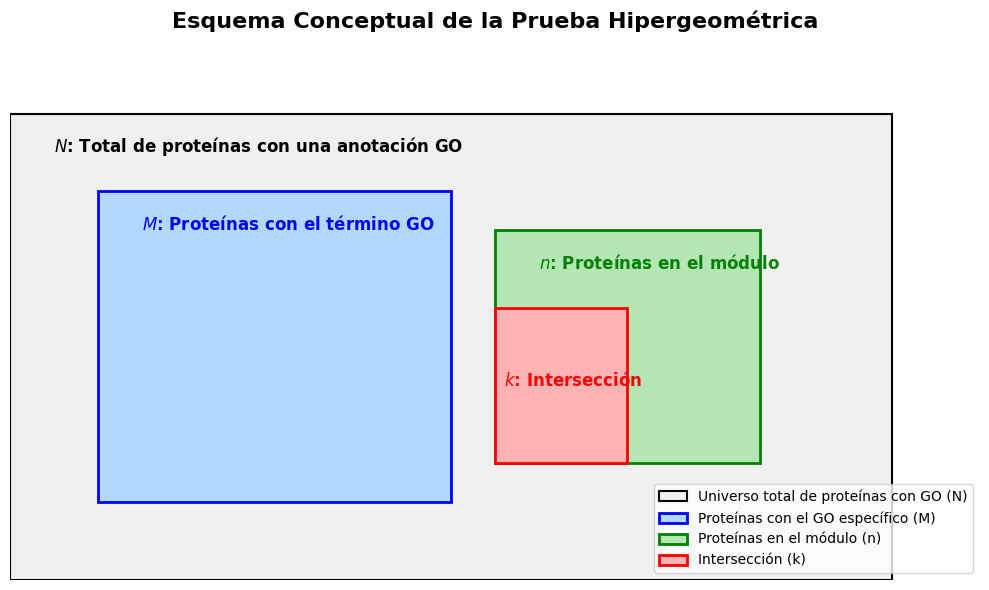


Gráfico geenrado.


In [19]:
if df_valid is not None and not df_valid.empty:
    print("\n--- Generando gráfico ---")
    
    # --- 2. GRÁFICO A: ESQUEMA DE LA PRUEBA HIPERGEOMÉTRICA (DIAGRAMA DE CAJAS) ---
    # Este gráfico explica conceptualmente los componentes de la prueba
    
    print("\nCreando el esquema conceptual de la prueba hipergeométrica...")
    
    fig, ax = plt.subplots(figsize=(10, 6))

    # Rectángulo del universo (N)
    universe = patches.Rectangle((0, 0), 10, 6, linewidth=1.5, edgecolor='black', facecolor='#f0f0f0', label='Universo total de proteínas con GO (N)')
    ax.add_patch(universe)
    ax.text(0.5, 5.5, '$N$: Total de proteínas con una anotación GO', fontsize=12, weight='bold', color='black')

    # Subgrupo de proteínas con el término GO específico (M)
    go_term = patches.Rectangle((1, 1), 4, 4, linewidth=2, edgecolor='blue', facecolor='#b2d8ff', label='Proteínas con el GO específico (M)')
    ax.add_patch(go_term)
    ax.text(1.5, 4.5, '$M$: Proteínas con el término GO', fontsize=12, weight='bold', color='blue')

    # Subgrupo del módulo de proteínas (n)
    module = patches.Rectangle((5.5, 1.5), 3, 3, linewidth=2, edgecolor='green', facecolor='#b3e6b3', label='Proteínas en el módulo (n)')
    ax.add_patch(module)
    ax.text(6.0, 4.0, '$n$: Proteínas en el módulo', fontsize=12, weight='bold', color='green')

    # Intersección (k)
    intersection = patches.Rectangle((5.5, 1.5), 1.5, 2.0, linewidth=2, edgecolor='red', facecolor='#ffb3b3', label='Intersección (k)')
    ax.add_patch(intersection)
    ax.text(5.6, 2.5, '$k$: Intersección', fontsize=12, weight='bold', color='red')

    ax.set_xlim(0, 11)
    ax.set_ylim(0, 7)
    ax.axis('off')
    ax.set_title("Esquema Conceptual de la Prueba Hipergeométrica", fontsize=16, weight='bold')
    ax.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

    
    print("\nGráfico geenrado.")
else:
    print("No se encontraron datos o el DataFrame está vacío. No se generarán gráficos.")



--- Generando gráficos para el análisis de enriquecimiento ---

Creando histograma de Z-scores...


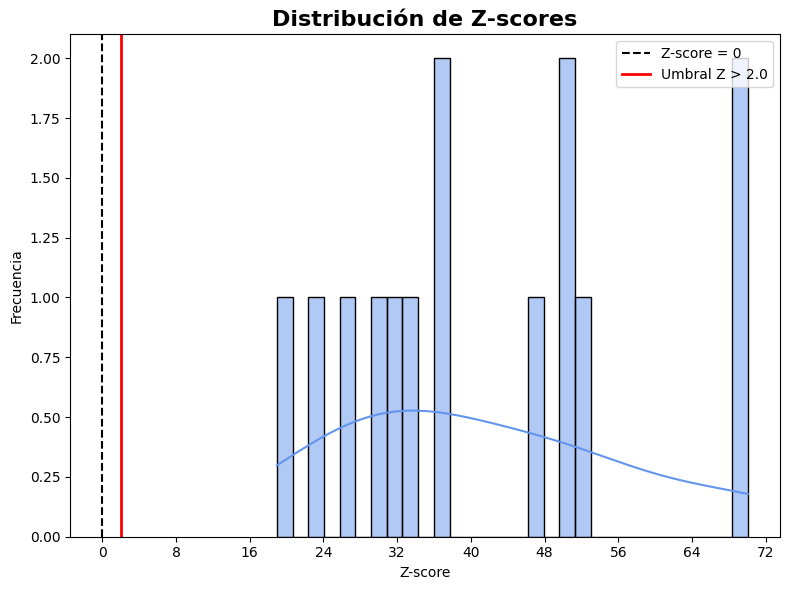


Creando histograma de Combined Scores...


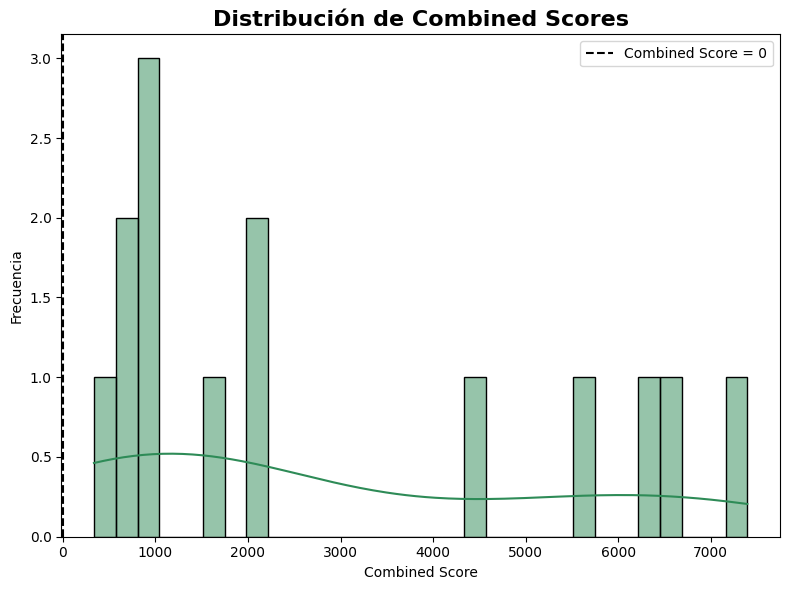


Gráficos generados correctamente.


In [20]:
if df_valid is not None and not df_valid.empty:
    print("\n--- Generando gráficos para el análisis de enriquecimiento ---")

    # --- Histograma de Z-scores ---
    print("\nCreando histograma de Z-scores...")

    plt.figure(figsize=(8, 6))
    sns.histplot(df_valid['representative_go_z_score'], kde=True, bins=30, color='cornflowerblue')
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Z-score = 0')
    threshold = 2.0  # Umbral sugerido
    plt.axvline(threshold, color='red', linestyle='-', linewidth=2, label=f'Umbral Z > {threshold}')
    plt.title("Distribución de Z-scores", fontsize=16, weight='bold')
    plt.xlabel("Z-score")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()

    # --- Histograma de Combined Scores ---
    print("\nCreando histograma de Combined Scores...")

    plt.figure(figsize=(8, 6))
    sns.histplot(df_valid['representative_combined_score'], kde=True, bins=30, color='seagreen')
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Combined Score = 0')
    plt.title("Distribución de Combined Scores", fontsize=16, weight='bold')
    plt.xlabel("Combined Score")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nGráficos generados correctamente.")
else:
    print("No se encontraron datos o el DataFrame está vacío. No se generarán gráficos.")


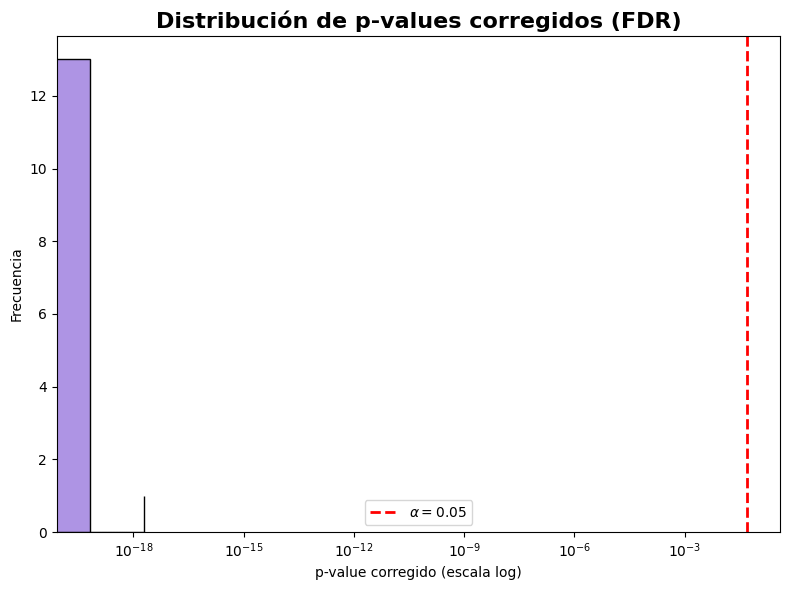

In [28]:
plt.figure(figsize=(8, 6))
sns.histplot(df_valid['representative_go_p_value'], bins=30, color='mediumpurple')
plt.axvline(0.05, color='red', linestyle='--', linewidth=2, label=r'$\alpha = 0.05$')
plt.xscale('log')  # Escala logarítmica
plt.title("Distribución de p-values corregidos (FDR)", fontsize=16, weight='bold')
plt.xlabel("p-value corregido (escala log)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

